<a href="https://colab.research.google.com/github/shreyashbhat1111/ML_Intern/blob/main/ML_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Project 3: Iris Flower Clustering Project

### Internship Assignment

**Objective:**  
Apply K-Means clustering and PCA on the Iris dataset, visualize the clusters, and compare predicted clusters with the true labels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add true labels
df['target'] = iris.target

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (150, 5)

Column Names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [4]:
# Select input features
X = iris.data

# True labels
y = iris.target

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (150, 4)
Labels Shape: (150,)


In [5]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardized data:")
print(X_scaled[:5])

Standardized data:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [6]:
# Apply K-Means clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit model and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Add predicted cluster to dataframe
df['Cluster'] = clusters

print("Predicted Cluster Labels:")
print(clusters[:20])

Predicted Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


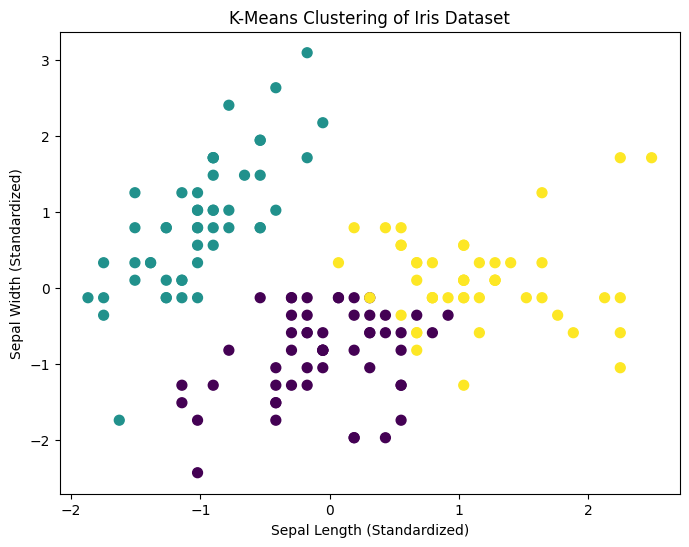

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    s=50
)

plt.xlabel('Sepal Length (Standardized)')
plt.ylabel('Sepal Width (Standardized)')
plt.title('K-Means Clustering of Iris Dataset')

plt.show()

In [8]:
# Apply PCA to reduce dimensions from 4 to 2
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape)
print("Reduced dimensions:", X_pca.shape)

Original dimensions: (150, 4)
Reduced dimensions: (150, 2)


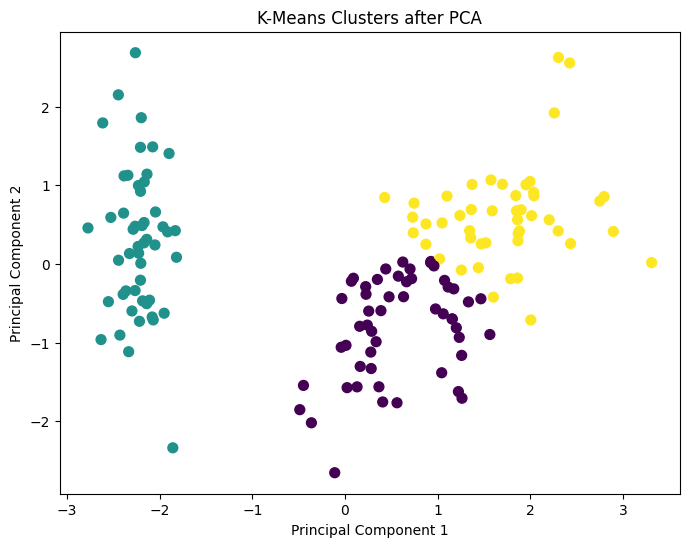

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=50
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters after PCA')

plt.show()

In [10]:
# Compare predicted clusters with true labels

comparison = pd.DataFrame({
    'True Label': y,
    'Predicted Cluster': clusters
})

comparison.head(20)

,True Label,Predicted Cluster
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
5,0,1
6,0,1
7,0,1
8,0,1
9,0,1


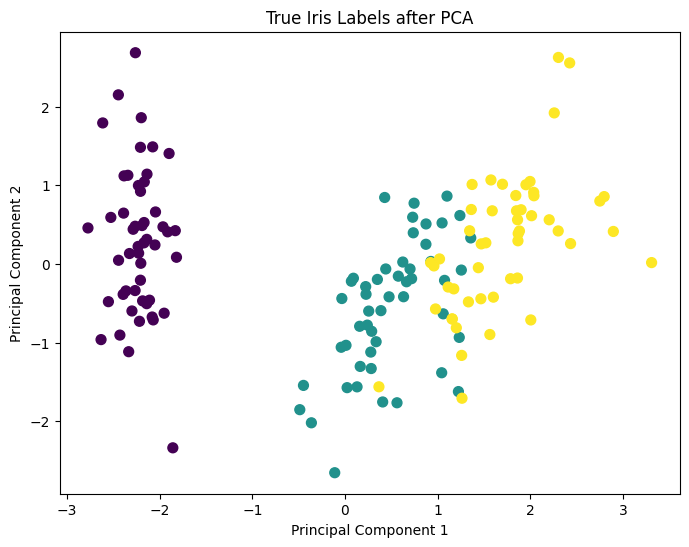

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    s=50
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('True Iris Labels after PCA')

plt.show()

In [12]:
cm = confusion_matrix(y, clusters)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 0 50  0]
 [39  0 11]
 [14  0 36]]


In [13]:
print("Cluster Centers:")

cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=iris.feature_names
)

cluster_centers

Cluster Centers:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.801887,2.673585,4.369811,1.413208
1,5.006000,3.428000,1.462000,0.246000
2,6.780851,3.095745,5.510638,1.972340


In [14]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained by 2 Components:")
print(pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.72962445 0.22850762]

Total Variance Explained by 2 Components:
0.9581320720000166


## Observations

1. The Iris dataset contains 150 flower samples with 4 numerical features.
2. K-Means clustering was applied with k = 3.
3. The dataset was standardized before applying K-Means.
4. PCA was used to reduce the four-dimensional dataset into two principal components.
5. The PCA scatter plot provides a clear visual representation of the clusters.
6. The predicted clusters were compared with the actual Iris class labels.
7. The clustering results show that some Iris classes form relatively distinct groups, while some overlap can occur between classes.

## Conclusion

In this project, K-Means clustering was successfully applied to the Iris dataset with three clusters. PCA was then used to reduce the dimensions of the dataset from four features to two principal components for visualization.

The cluster visualization and comparison with the true labels demonstrate how unsupervised machine learning can identify natural groupings in data without using the class labels during clustering.

This project provided practical understanding of K-Means clustering, PCA, data standardization, and visualization.

📘 Mini Project 3: Iris Flower Clustering Project

├── Import Libraries
├── Load Iris Dataset
├── Understand Dataset
├── Select Features
├── Standardize Data
├── Apply K-Means (k=3)
├── Visualize K-Means Clusters
├── Apply PCA
├── Visualize PCA Clusters
├── Compare Predicted vs True Labels
├── Confusion Matrix
├── Cluster Centers
├── PCA Explained Variance
├── Observations
└── Conclusion